In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def xavier_init(shape):
    fan_in, fan_out = shape
    std = np.sqrt(2 / (fan_in + fan_out))
    return torch.randn(fan_in, fan_out) * std

def kaiming_init(shape):
    fan_in, _ = shape
    std = np.sqrt(2 / fan_in)
    return torch.randn(fan_in, shape[1]) * std

In [3]:
def create_network(init="xavier"):
    layers = []
    sizes = [64] + [64] * 19 + [10]

    for i in range(len(sizes)-1):
        shape = (sizes[i], sizes[i+1])

        if init == "xavier":
            W = xavier_init(shape)
        else:
            W = kaiming_init(shape)

        W.requires_grad = True
        layers.append(W)

    return layers

In [4]:
def forward(x, weights):
    activations = []

    for W in weights[:-1]:
        x = x @ W
        x = torch.relu(x)
        activations.append(x)

    x = x @ weights[-1]
    activations.append(x)

    return x, activations

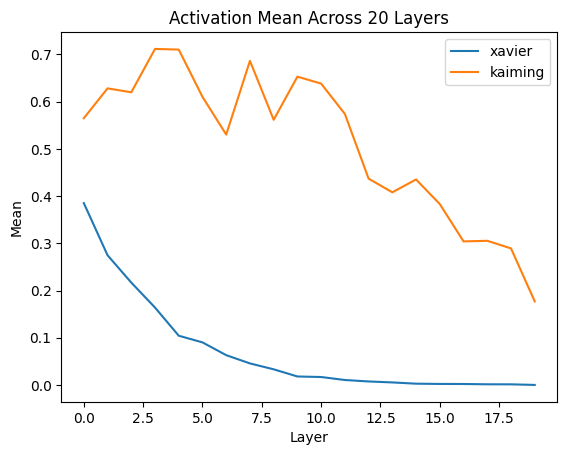

In [5]:
X = torch.randn(32, 64)

for init in ["xavier", "kaiming"]:

    weights = create_network(init)

    output, activations = forward(X, weights)

    loss = output.mean()
    loss.backward()

    act_mean = [a.mean().item() for a in activations]
    grad_mean = [W.grad.abs().mean().item() for W in weights]

    plt.plot(act_mean, label=init)

plt.title("Activation Mean Across 20 Layers")
plt.xlabel("Layer")
plt.ylabel("Mean")
plt.legend()
plt.show()

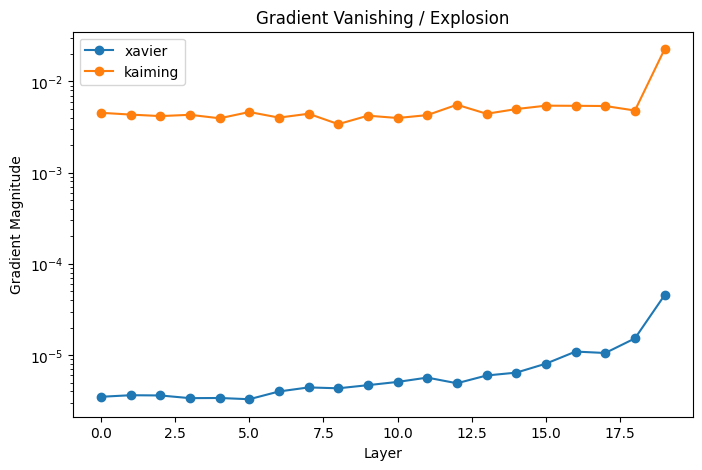

In [6]:
plt.figure(figsize=(8, 5))

for init in ["xavier", "kaiming"]:

    weights = create_network(init)

    output, _ = forward(X, weights)
    output.mean().backward()

    grads = [
        W.grad.abs().mean().item()
        for W in weights
    ]

    plt.plot(grads, marker="o", label=init)

plt.yscale("log")
plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Gradient Vanishing / Explosion")
plt.legend()
plt.show()

In [7]:
print("Xavier and Kaiming initialization comparison completed.")
print("The plots show activation and gradient behavior across 20 layers.")

Xavier and Kaiming initialization comparison completed.
The plots show activation and gradient behavior across 20 layers.
